# Synthetic Polarization Pipeline
Call `simulate_field(geometry, turbulence, ...)` to generate P and PA maps for any combination of field geometry and turbulence model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnetic_fields import simulate_field
from plotting_functions import plot_comparison, plot_P_distributions, run_skewness_sweep 

## Step 1 — Visual sanity check: P and PA maps

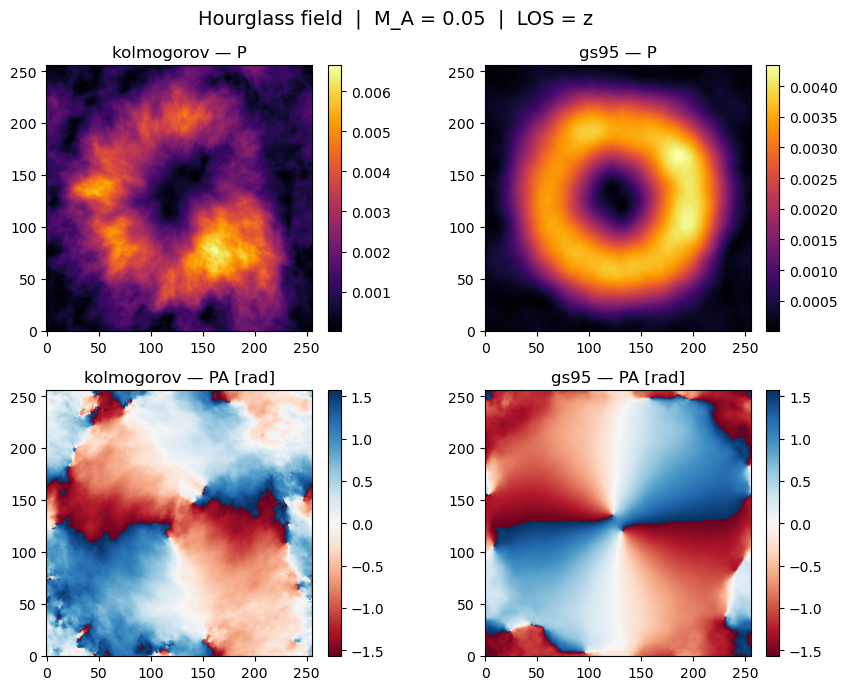


  Mean P : kolmogorov = 0.0020     gs95 = 0.0017
  Std  P : kolmogorov = 0.0014    gs95 = 0.0013


In [5]:
# geometry options: 'uniform', 'wavy', 'helical', 'hourglass'
# turbulence options: 'random', 'kolmogorov', 'gs95'

plot_comparison(geometry     = 'hourglass',
                turbulence_a = 'kolmogorov',
                turbulence_b = 'gs95',
                iaxis=2, alpha=0, M_A=0.05, g_size=256)

## Step 2 — P distributions as a function of M_A

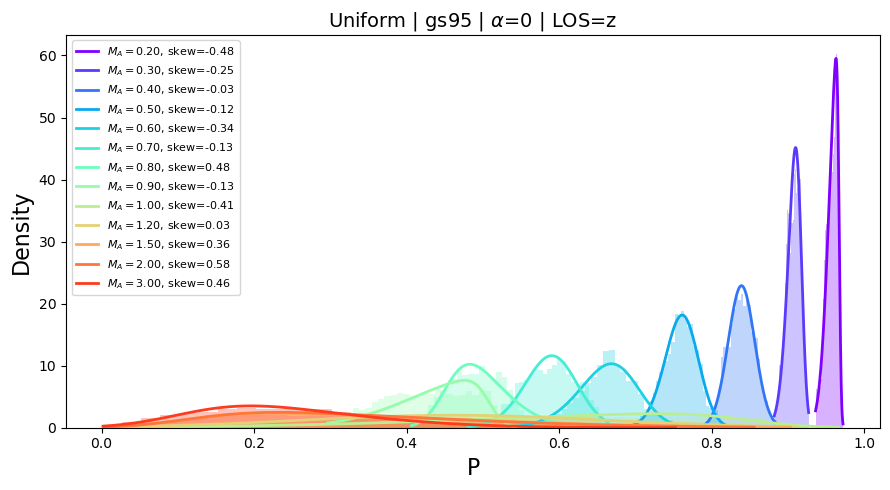

In [10]:
mach_vals, skews = plot_P_distributions(geometry='uniform', turbulence='gs95', g_size=128)

## Step 3 — Skewness vs M_A with fit and ±1σ envelope

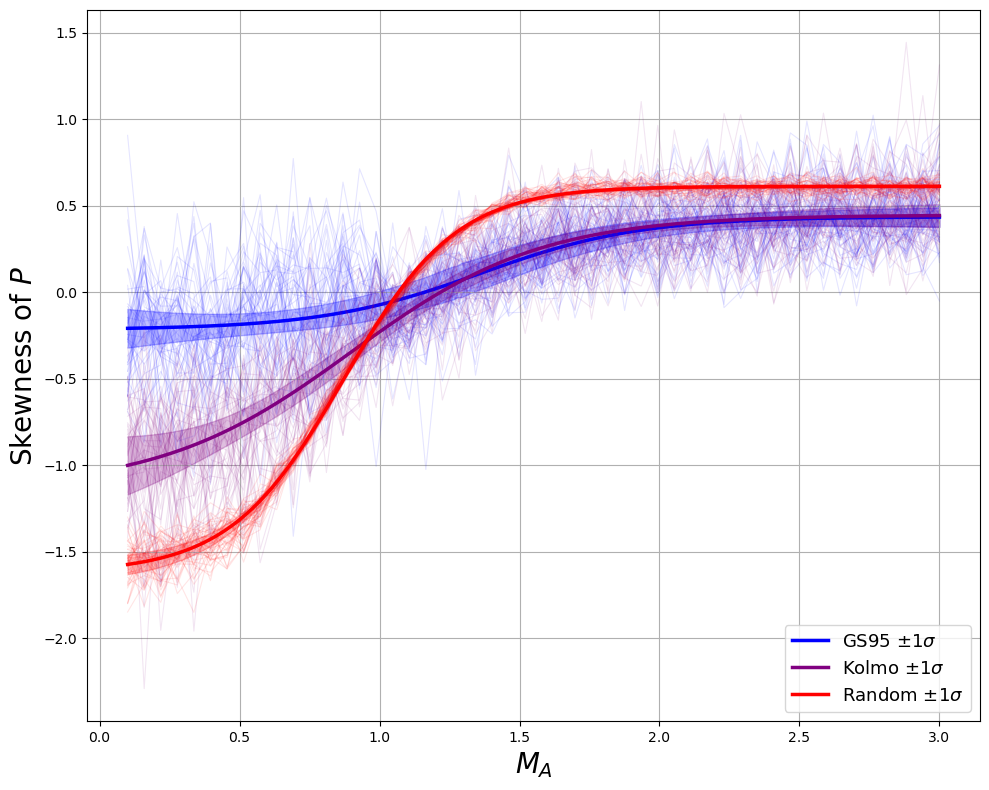

In [11]:
plt.figure(figsize=(10, 8))

run_skewness_sweep(geometry='uniform', turbulence='gs95', g_size=64, n_runs=50, 
                   fit_method='tanh', color='blue',  label=r'GS95 $\pm1\sigma$')

run_skewness_sweep(geometry='uniform', turbulence='kolmogorov', g_size=64, n_runs=50,
                   fit_method='tanh', color='purple',   label=r'Kolmo $\pm1\sigma$')

run_skewness_sweep(geometry='uniform', turbulence='random', g_size=64, n_runs=50,
                   fit_method='tanh', color='red',   label=r'Random $\pm1\sigma$')

plt.xlabel(r'$M_A$', fontsize=20)
plt.ylabel('Skewness of $P$', fontsize=20)
plt.grid(True)
plt.legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.show()